In [232]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
from scipy.interpolate import interp1d
sns.set_theme(style="darkgrid")

In [125]:
# Select the drone
drone = 'M300' # 'M300' or 'MAVIC'

In [126]:
basefolder = '/home/agostino/Desktop/droni/volo_20251103_arluno/' # Adjust it according to the machine.

path_to_fr = basefolder+'data/'+drone+'/FlightRecords/'

listoffiles_fr = sorted(glob.glob(path_to_fr+'*csv'))
listoffiles_fr # It contains all files the selected directory.

['/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[11-34-11].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[11-34-21].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[11-46-35].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[11-59-14].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[12-11-51].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[14-34-32].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[15-01-14].csv',
 '/home/agostino/Desktop/droni/volo_20251103_arluno/data/M300/FlightRecords/DJIFlightRecord_2025-11-03_[15-19-42].csv',
 '/home/agostino/Desktop/droni/volo_2025

In [127]:
# Read all files in the listoffiles_fr

df = pd.concat((pd.read_csv(f) for f in listoffiles_fr), ignore_index=True)
    
# Select only relevant columns
fr_df = df[['CUSTOM.dateTime', 'OSD.latitude', 'OSD.longitude', 'OSD.height', 'OSD.xSpeed', 'OSD.ySpeed', 'OSD.zSpeed', 'OSD.yaw', 'OSD.pitch', 'OSD.roll']].copy()

/tmp/ipykernel_97819/660458111.py:3: DtypeWarning: Columns (19,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in listoffiles_fr), ignore_index=True)
/tmp/ipykernel_97819/660458111.py:3: DtypeWarning: Columns (19,114) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in listoffiles_fr), ignore_index=True)


In [128]:
# Convert time info in UTC datetime.
fr_df['CUSTOM.dateTime_dt'] = pd.to_datetime(fr_df['CUSTOM.dateTime'], format='ISO8601',utc=True)

# Filter sampling errors.
median_time = fr_df['CUSTOM.dateTime_dt'].median()
i_to_drop = fr_df.loc[(fr_df['CUSTOM.dateTime_dt'] > median_time+pd.Timedelta(1,'day')) | (fr_df['CUSTOM.dateTime_dt'] < median_time-pd.Timedelta(1,'day'))].index
print(f"Dropping {len(i_to_drop)} rows with datetime errors.")
fr_df.drop(axis=0, index=i_to_drop,inplace=True)
fr_df

Dropping 27 rows with datetime errors.


,CUSTOM.dateTime,OSD.latitude,OSD.longitude,OSD.height,OSD.xSpeed,OSD.ySpeed,OSD.zSpeed,OSD.yaw,OSD.pitch,OSD.roll,CUSTOM.dateTime_dt
1,2025-11-03T10:34:11.866Z,45.520438,8.942694,0.0,0.0,0.0,0.0,88.5,-1.2,-2.8,2025-11-03 10:34:11.866000+00:00
2,2025-11-03T10:34:11.967Z,45.520438,8.942694,0.0,0.0,0.0,0.0,88.6,-1.2,-2.8,2025-11-03 10:34:11.967000+00:00
3,2025-11-03T10:34:12.068Z,45.520438,8.942694,0.0,0.0,0.0,0.0,88.6,-1.2,-2.8,2025-11-03 10:34:12.068000+00:00
4,2025-11-03T10:34:12.171Z,45.520438,8.942694,0.0,0.0,0.0,0.0,88.6,-1.2,-2.8,2025-11-03 10:34:12.171000+00:00
5,2025-11-03T10:34:12.272Z,45.520438,8.942694,0.0,0.0,0.0,0.0,88.6,-1.2,-2.8,2025-11-03 10:34:12.272000+00:00
...,...,...,...,...,...,...,...,...,...,...,...
72478,2025-11-03T15:31:42.852Z,45.520465,8.942787,0.8,0.0,0.0,0.0,158.9,0.2,-1.1,2025-11-03 15:31:42.852000+00:00
72479,2025-11-03T15:31:42.852Z,45.520465,8.942787,0.8,0.0,0.0,0.0,158.9,0.2,-1.2,2025-11-03 15:31:42.852000+00:00
72480,2025-11-03T15:31:42.954Z,45.520465,8.942787,0.8,0.0,0.0,0.0,158.9,0.3,-1.2,2025-11-03 15:31:42.954000+00:00
72481,2025-11-03T15:31:43.055Z,45.520465,8.942787,0.8,0.0,0.0,0.0,158.9,0.3,-1.2,2025-11-03 15:31:43.055000+00:00


In [159]:
# Read the trisonica and imet data
path_to_tris = basefolder + 'data/trisonica/'
path_to_imet = basefolder + 'data/imet/'

listoffiles_tris = sorted(glob.glob(path_to_tris+'*csv'))
listoffiles_tris
df_tris = pd.concat((pd.read_csv(f,sep=';',header=8,skipinitialspace=True) for f in listoffiles_tris), ignore_index=True)
df_tris['Time (UTC) dt'] = pd.to_datetime('2025-11-03 '+df_tris['Time (UTC)']) 
time_tris = df_tris['Time (UTC) dt'].values
print(df_tris.columns)

listoffiles_imet = sorted(glob.glob(path_to_imet+'*csv'))
listoffiles_imet[0]
df_imet = pd.read_csv(listoffiles_imet[0])
df_imet # The file is not right!!!!

Index(['Time (UTC)', 'SKH1_70727633.pr', 'SKH1_70727633.bat',
       'SKH1_70727633.temp', 'SKH1_70727633.rh', 'SKH1_70727633.lat',
       'SKH1_70727633.lon', 'SKH1_70727633.alt', 'C.wspd', 'C.wdir', 'C.windU',
       'C.windV', 'C.windW', 'C.temp', 'C.rh', 'C.pr', 'C.pitch', 'C.roll',
       'C.heading', 'Time (UTC) dt'],
      dtype='object')


,Time,COM Elapse,0-Pressure,0-Pressure Temperature,0-Humidity,0-Humidity Temperature,1-EE03 Humidity,1-EE03 Humidity Temperature,2-Sensor Temperature,2-Object Temperature,...,XQ-iMet-XQ Air Temperature,XQ-iMet-XQ Humidity,XQ-iMet-XQ Humidity Temp,XQ-iMet-XQ Date,XQ-iMet-XQ Time,XQ-iMet-XQ Longitude,XQ-iMet-XQ Latitude,XQ-iMet-XQ Altitude,XQ-iMet-XQ Sat Count,Unnamed: 46
0,2025/11/04 14:40:40.1850,0.000,0,0,0,0,0,0,0,0,...,20.49,39.7,20.99,2015/10/18,00:00:11,0.0,0.0,-17.0,0,NaN
1,2025/11/04 14:40:41.2534,1.068,0,0,0,0,0,0,0,0,...,21.18,48.7,22.43,2015/10/18,00:01:54,0.0,0.0,-17.0,0,NaN
2,2025/11/04 14:40:41.2795,1.095,0,0,0,0,0,0,0,0,...,21.20,48.6,22.46,2015/10/18,00:01:55,0.0,0.0,-17.0,0,NaN
3,2025/11/04 14:40:41.3014,1.116,0,0,0,0,0,0,0,0,...,21.19,48.6,22.46,2015/10/18,00:01:56,0.0,0.0,-17.0,0,NaN
4,2025/11/04 14:40:41.3363,1.151,0,0,0,0,0,0,0,0,...,21.23,48.6,22.48,2015/10/18,00:01:57,0.0,0.0,-17.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9946,2025/11/04 14:44:59.7366,259.552,0,0,0,0,0,0,0,0,...,20.48,39.7,20.97,2015/10/18,00:00:08,0.0,0.0,-17.0,0,NaN
9947,2025/11/04 14:44:59.7583,259.573,0,0,0,0,0,0,0,0,...,20.49,39.7,20.97,2015/10/18,00:00:09,0.0,0.0,-17.0,0,NaN
9948,2025/11/04 14:44:59.7739,259.589,0,0,0,0,0,0,0,0,...,20.47,39.7,20.97,2015/10/18,00:00:10,0.0,0.0,-17.0,0,NaN
9949,2025/11/04 14:44:59.8053,259.620,0,0,0,0,0,0,0,0,...,20.49,39.7,20.99,2015/10/18,00:00:11,0.0,0.0,-17.0,0,NaN


(np.float64(20395.583333333332), np.float64(20395.590277777777))

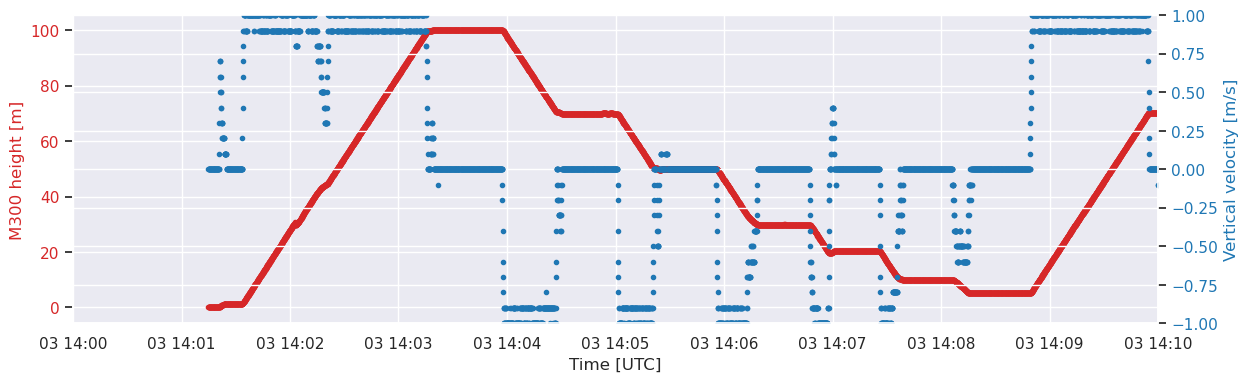

In [130]:
# Plot a time series of the height of the drone for all files considered, together with the vertical speed.

fig,ax1=plt.subplots(1,1,figsize=(14,4))

plt.xlabel('Time [UTC]')
plt.ylabel(drone + ' height [m]')

color = 'tab:red'
ax1.set_xlabel('Time [UTC]')
ax1.set_ylabel(drone+' height [m]', color=color)
ax1.plot(fr_df['CUSTOM.dateTime_dt'],fr_df['OSD.height'],'.',color=color)
ax1.tick_params(axis='y', labelcolor=color)
             
ax2 = ax1.twinx() 

color = 'tab:blue'
ax2.set_ylabel('Vertical velocity [m/s]', color=color) # it is positive going down!
ax2.plot(fr_df['CUSTOM.dateTime_dt'],-fr_df['OSD.zSpeed'],'.',color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([-1,1])

# Select a time window to zoom in or comment to look at the full timeseries
#ax1.set_xlim([np.datetime64('2025-11-03 10:30:00'),np.datetime64('2025-11-03 11:15:00')]) # three hoverings
ax1.set_xlim([np.datetime64('2025-11-03 14:00:00'),np.datetime64('2025-11-03 14:10:00')]) # a vertical profile

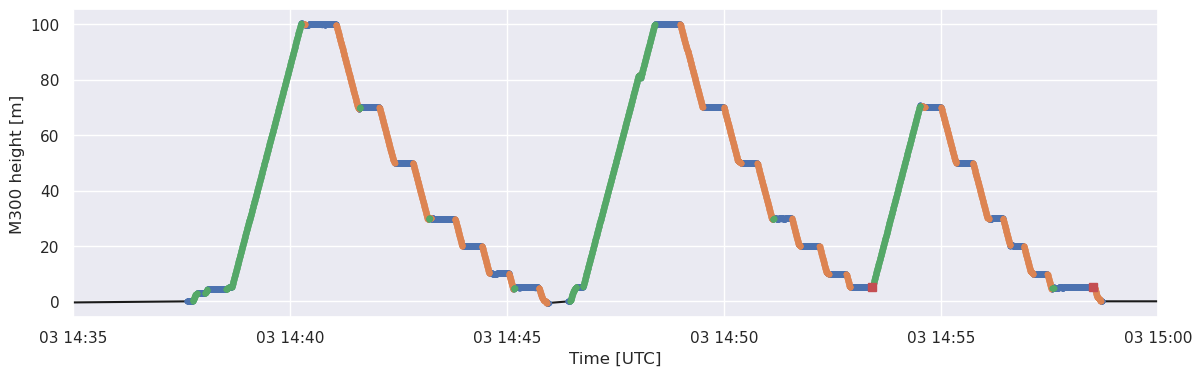

In [220]:
# We can identify the following cathegories: ascent, descent, hovering
# ascent: zSpeed < -0.01 m/s
# descent: zSpeed > 0.01 m/s
# hovering in all other cases

fig,ax1=plt.subplots(1,1,figsize=(14,4))

plt.xlabel('Time [UTC]')
plt.ylabel(drone + ' height [m]')

time = fr_df['CUSTOM.dateTime_dt'].values
height = fr_df['OSD.height'].values
zs = -fr_df['OSD.zSpeed'].values # We change sign because it is positive going down.

ax1.set_xlabel('Time [UTC]')
ax1.set_ylabel(drone+' height [m]')
ax1.plot(time,height,'-k')
thresh = 0.03 # m/s
ax1.plot(time[np.abs(zs)<thresh],height[np.abs(zs)<thresh],'.')
ax1.plot(time[zs<-thresh],height[zs<-thresh],'.')
ax1.plot(time[zs>thresh],height[zs>thresh],'.')
ax1.tick_params(axis='y')
    
# Select a time window to zoom in or comment to look at the full timeseries
#ax1.set_xlim([np.datetime64('2025-11-03 10:30:00'),np.datetime64('2025-11-03 11:15:00')]) # three hoverings
#ax1.set_xlim([np.datetime64('2025-11-03 14:20:00'),np.datetime64('2025-11-03 14:40:00')]) # free
#ax1.set_xlim([np.datetime64('2025-11-03 14:00:00'),np.datetime64('2025-11-03 14:10:00')]) # a vertical profile
ax1.set_xlim([np.datetime64('2025-11-03 14:35:00'),np.datetime64('2025-11-03 15:00:00')]) # free

ax1.plot([start,end],[5,5],'rs')

In [308]:
# Profiles of the vertical profiles

#1
start = np.datetime64('2025-11-03 14:01:34')
end = np.datetime64('2025-11-03 14:08:50')
label_title = 'profile1'
"""
#2
start = np.datetime64('2025-11-03 14:08:50')
end = np.datetime64('2025-11-03 14:13:40')
label_title = 'profile2'

#3
start = np.datetime64('2025-11-03 14:38:35')
end = np.datetime64('2025-11-03 14:45:38')
label_title = 'profile3'

#4
start = np.datetime64('2025-11-03 14:46:45')
end = np.datetime64('2025-11-03 14:53:25')
label_title = 'profile4'

#5
start = np.datetime64('2025-11-03 14:53:25')
end = np.datetime64('2025-11-03 14:58:30')
label_title = 'profile5'
"""

"\n#2\nstart = np.datetime64('2025-11-03 14:08:50')\nend = np.datetime64('2025-11-03 14:13:40')\nlabel_title = 'profile2'\n\n#3\nstart = np.datetime64('2025-11-03 14:38:35')\nend = np.datetime64('2025-11-03 14:45:38')\nlabel_title = 'profile3'\n\n#4\nstart = np.datetime64('2025-11-03 14:46:45')\nend = np.datetime64('2025-11-03 14:53:25')\nlabel_title = 'profile4'\n\n#5\nstart = np.datetime64('2025-11-03 14:53:25')\nend = np.datetime64('2025-11-03 14:58:30')\nlabel_title = 'profile5'\n"

In [309]:
# Extract data only in the time frame of interest

df_subset = fr_df[(time>=start) & (time<=end)]
df_subset_tris = df_tris[(time_tris>=start) & (time_tris<=end)]

In [310]:
# Profiles of wind speed, air temperature and RH.
# Ascending, descending and hovering.

# Interpolate the OSD.height and OSD.zSpeed on the trisonica time axis
height_fr_s = df_subset['OSD.height'].values
zs_fr_s = df_subset['OSD.zSpeed'].values
time_fr_s = (df_subset['CUSTOM.dateTime_dt'] - pd.to_datetime('2025-11-03',utc=True)) // pd.Timedelta('1s')
# Note that we are downgrading to 1 s frequency!!!!!!!!!!!!!

f_h = interp1d(time_fr_s,height_fr_s)
f_zs = interp1d(time_fr_s,zs_fr_s)

time_tris_s = (df_subset_tris['Time (UTC) dt'] - pd.to_datetime('2025-11-03')) // pd.Timedelta('1s')
height_tris_s = f_h(time_tris_s)
zs_tris_s = -f_zs(time_tris_s) # Make the vertical velocity positive going up!

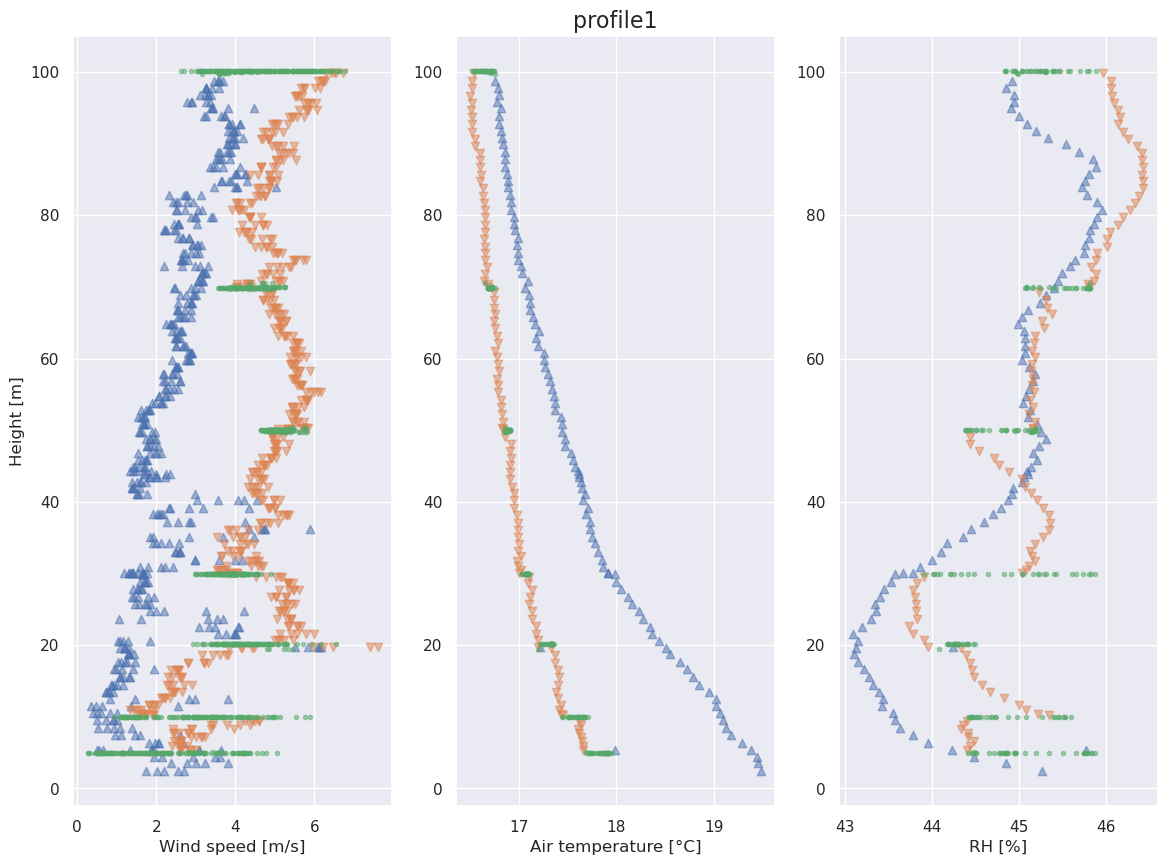

In [311]:
fig,ax=plt.subplots(1,3,figsize=(14,10))

plt.xlabel('Time [UTC]')

x = df_subset_tris['C.wspd'].values
y = height_tris_s

ax[0].set_xlabel('Wind speed [m/s]')
ax[0].set_ylabel('Height [m]')
ax[0].scatter(x[zs_tris_s>0.2],y[zs_tris_s>0.2],marker='^',alpha=.5) # ascending
ax[0].scatter(x[zs_tris_s<-0.2],y[zs_tris_s<-0.2],marker='v',alpha=.5) # descending
ax[0].scatter(x[np.abs(zs_tris_s)<0.2],y[np.abs(zs_tris_s)<0.2],marker='.',alpha=.5) # hovering

x = df_subset_tris['SKH1_70727633.temp'].values

ax[1].set_title(label_title,fontsize=16)
ax[1].set_xlabel('Air temperature [°C]')
ax[1].scatter(x[zs_tris_s>0.2],y[zs_tris_s>0.2],marker='^',alpha=.5) # ascending
ax[1].scatter(x[zs_tris_s<-0.2],y[zs_tris_s<-0.2],marker='v',alpha=.5) # descending
ax[1].scatter(x[np.abs(zs_tris_s)<0.2],y[np.abs(zs_tris_s)<0.2],marker='.',alpha=.5) # hovering

x = df_subset_tris['SKH1_70727633.rh'].values

ax[2].set_xlabel('RH [%]')
ax[2].scatter(x[zs_tris_s>0.2],y[zs_tris_s>0.2],marker='^',alpha=.5) # ascending
ax[2].scatter(x[zs_tris_s<-0.2],y[zs_tris_s<-0.2],marker='v',alpha=.5) # descending
ax[2].scatter(x[np.abs(zs_tris_s)<0.2],y[np.abs(zs_tris_s)<0.2],marker='.',alpha=.5) # hovering

plt.savefig('vertical_'+label_title+'.png',bbox_inches='tight')

In [175]:
# Timeseries of the wind speed and direction, air temperature and humidity during the hoverings. #MAVIC

#1 @ 3m
start = np.datetime64('2025-11-03 10:34:18')
end = np.datetime64('2025-11-03 10:43:10')
label_title = 'hovering3m'
"""
#2 @ 50m
start = np.datetime64('2025-11-03 10:47:55')
end = np.datetime64('2025-11-03 10:55:10')
label_title = 'hovering50m'

#3 @ 8m
start = np.datetime64('2025-11-03 11:00:55')
end = np.datetime64('2025-11-03 11:09:50')
label_title = 'hovering8m'

#4 @ 20m
start = np.datetime64('2025-11-03 13:35:10')
end = np.datetime64('2025-11-03 13:50:00')
label_title = 'hovering20m'

#5 @ 80m # for M300 only
start = np.datetime64('2025-11-03 14:21:30')
end = np.datetime64('2025-11-03 14:32:10')
label_title = 'hovering80m'
"""

"\n#2 @ 50m\nstart = np.datetime64('2025-11-03 10:47:55')\nend = np.datetime64('2025-11-03 10:55:10')\nlabel_title = 'hovering50m'\n\n#3 @ 8m\nstart = np.datetime64('2025-11-03 11:00:55')\nend = np.datetime64('2025-11-03 11:09:50')\nlabel_title = 'hovering8m'\n\n#4 @ 20m\nstart = np.datetime64('2025-11-03 13:35:10')\nend = np.datetime64('2025-11-03 13:50:00')\nlabel_title = 'hovering20m'\n\n#5 @ 80m # for M300 only\nstart = np.datetime64('2025-11-03 14:21:30')\nend = np.datetime64('2025-11-03 14:32:10')\nlabel_title = 'hovering80m'\n"

In [176]:
# Extract data only in the time frame of interest

df_subset = fr_df[(time>=start) & (time<=end)]
df_subset_tris = df_tris[(time_tris>=start) & (time_tris<=end)]

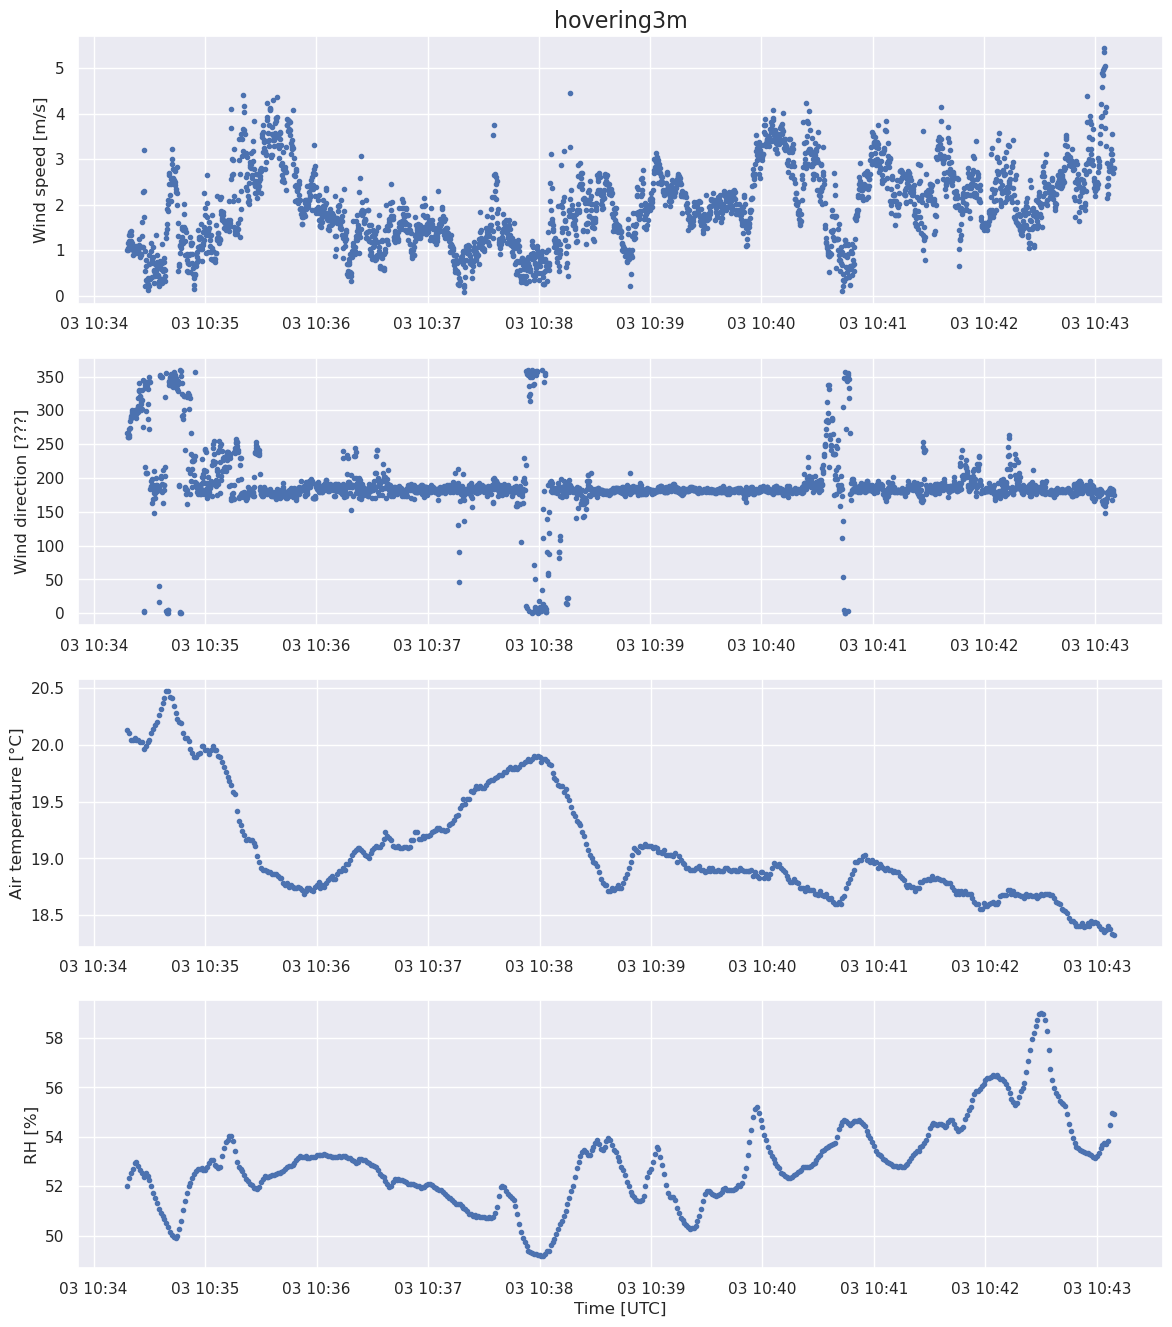

In [177]:
# Plot the most relevant variables

fig,ax=plt.subplots(4,1,figsize=(14,16))

plt.xlabel('Time [UTC]')

ax[0].set_title(label_title,fontsize=16)
ax[0].set_ylabel('Wind speed [m/s]')
ax[0].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['C.wspd'],'.')

ax[1].set_ylabel('Wind direction [???]')
ax[1].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['C.wdir'],'.')

ax[2].set_ylabel('Air temperature [°C]')
ax[2].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['SKH1_70727633.temp'],'.')

ax[3].set_ylabel('RH [%]')
ax[3].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['SKH1_70727633.rh'],'.')

plt.savefig('timeseries_'+label_title+'.png',bbox_inches='tight')